**EDA on our merged OULAD**

## Header

In [33]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv('ouladmerg.csv')

We look at what columns there are, and divide these into columns related to the unique student, columns related to VLE interactions, and columns related to assessments.

In [35]:
df.columns

Index(['id_student', 'code_module', 'code_presentation', 'date', 'forumng',
       'homepage', 'oucontent', 'subpage', 'url', 'resource', 'glossary',
       'dataplus', 'oucollaborate', 'quiz', 'ouelluminate', 'sharedsubpage',
       'questionnaire', 'page', 'externalquiz', 'ouwiki', 'dualpane',
       'repeatactivity', 'folder', 'htmlactivity', 'id_assessment',
       'is_banked', 'score', 'assessment_type', 'due_date', 'weight',
       'module_presentation_length', 'gender', 'region', 'highest_education',
       'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits',
       'disability', 'final_result', 'date_registration',
       'date_unregistration'],
      dtype='object')

In [36]:
tag_feats = df.columns[:3]
module_feats = [df.columns[30]]
dataline_feats = ['date']
vle_feats = df.columns[4:24]
assess_feats = df.columns[24:30]
student_feats = df.columns[31:] 
tag_feats, student_feats, module_feats, vle_feats, assess_feats

(Index(['id_student', 'code_module', 'code_presentation'], dtype='object'),
 Index(['gender', 'region', 'highest_education', 'imd_band', 'age_band',
        'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result',
        'date_registration', 'date_unregistration'],
       dtype='object'),
 ['module_presentation_length'],
 Index(['forumng', 'homepage', 'oucontent', 'subpage', 'url', 'resource',
        'glossary', 'dataplus', 'oucollaborate', 'quiz', 'ouelluminate',
        'sharedsubpage', 'questionnaire', 'page', 'externalquiz', 'ouwiki',
        'dualpane', 'repeatactivity', 'folder', 'htmlactivity'],
       dtype='object'),
 Index(['id_assessment', 'is_banked', 'score', 'assessment_type', 'due_date',
        'weight'],
       dtype='object'))

## Missing data

We study / visualize how much of our data is missing.

(Note: no data is missing from features in `tag_feats`, `module_feats`, `date`, `vle_feats`)

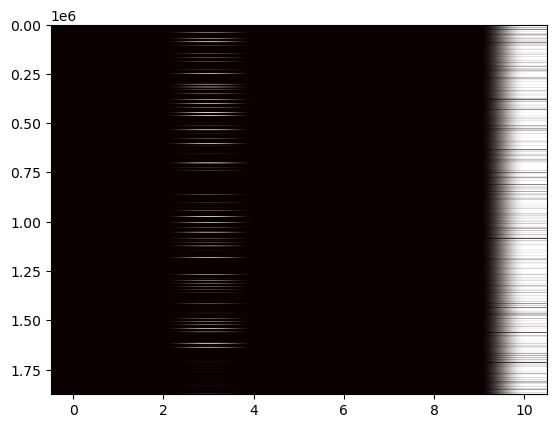

In [46]:
plt.imshow(df[student_feats].isnull(), cmap='hot', aspect='auto')

There are a few missing `imd_band`s and lots of missing `date_unregistration`s.

In [47]:
def how_missing(feature, df):
    m = sum(df[feature].isnull())
    return (m, f"{(m / len(df)):.4f}")

In [48]:
print(how_missing('imd_band',df),  how_missing('date_unregistration',df))

(98792, '0.0527') (1706150, '0.9097')


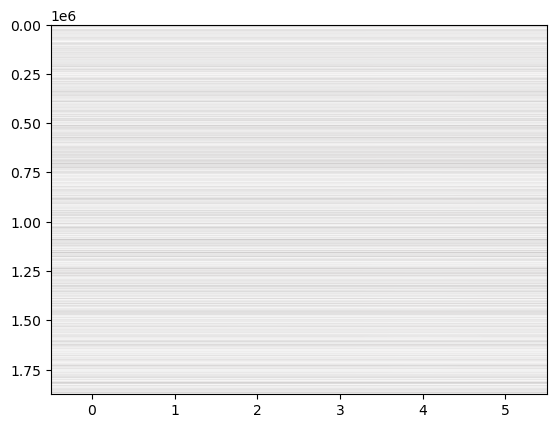

In [49]:
plt.imshow(df[assess_feats].isnull(), cmap='hot', aspect='auto')

Lots of missing `assess_feats`; it seems all these correspond to data lines where students have VLE-type interactions but not assessment interactions.

In [50]:
print(how_missing('id_assessment',df),  how_missing('assessment_type', df), how_missing('score',df))

(1701584, '0.9073') (1701584, '0.9073') (1701757, '0.9074')


In [51]:
df[df.id_assessment.isnull() & ~df.score.isnull()]

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,...,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration


This resolves the mystery of the missing `score` fields: `score`s come from assessments; the small number of rows which are missing `score`s but not other `assess_feat` features probably come from students who did / submitted an assignment but did not receive a score on it for various reasons. We remark that these are all tutor-marked modules, across all modules and all presentations. 

In [52]:
df[~df.id_assessment.isnull() & df.score.isnull()].assessment_type.describe()

count     173
unique      1
top       TMA
freq      173
Name: assessment_type, dtype: object

In [53]:
df[~df.id_assessment.isnull() & df.score.isnull()].code_module.describe()

count     173
unique      7
top       BBB
freq       53
Name: code_module, dtype: object

In [54]:
df[~df.id_assessment.isnull() & df.score.isnull()].code_presentation.describe()

count       173
unique        4
top       2013B
freq         48
Name: code_presentation, dtype: object

## Data aggregation 

For ease of processing (especially given the structure of the missing features), I am going to split into VLE and assessment dataframes. We will want to keep student data in both.

In [55]:
common_feats = list(tag_feats) + list(student_feats) + list(module_feats) + list(dataline_feats)
df_vle = df[df.id_assessment.isnull()][common_feats + list(vle_feats)]
df_assess = df[~df.id_assessment.isnull()][common_feats + list(assess_feats)]

In [56]:
df_vle[vle_feats].sample(3)

,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity
1044770,5,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0
736676,0,3,20,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0
1179522,9,4,0,0,0,0,0,0,1,1.0,0,0,0,0,0,0,0,0,0,0


In [57]:
df_assess.sample(3)


,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,date_registration,date_unregistration,module_presentation_length,date,id_assessment,is_banked,score,assessment_type,due_date,weight
411478,484010,FFF,2014J,M,East Anglian Region,A Level or Equivalent,70-80%,35-55,0,60,...,-109.0,NaN,269,243.0,34904.0,0.0,92.0,CMA,241.0,0.0
1749395,2198952,DDD,2013J,M,Ireland,A Level or Equivalent,NaN,35-55,0,60,...,-35.0,NaN,261,23.0,25348.0,0.0,80.0,TMA,25.0,10.0
1702523,1878918,FFF,2013B,M,Scotland,HE Qualification,0-10%,35-55,0,60,...,-30.0,NaN,240,99.0,34862.0,0.0,60.0,TMA,89.0,25.0


**Aggregation strategy**

For the rest of the notebook, we will look at data aggregated for the three weeks.
We merge all data rows with `date`s within this time frame corresponding to each (student, module, presentation).

In [58]:
cutoff = 22

In [59]:
df3w_vle = df_vle[df_vle.date<cutoff].drop(['date'], axis=1)
X1 = df3w_vle.drop(student_feats,axis=1).groupby(list(tag_feats)).sum()
X2y = df3w_vle[list(tag_feats)+list(student_feats)].groupby(list(tag_feats)).last()
df3w_vle = pd.concat([X1,X2y],axis=1)

In [60]:
df3w_vle[vle_feats].sample()

,,,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity
id_student,code_module,code_presentation,,,,,,,,,,,,,,,,,,,,
579125,GGG,2014J,0,6,0,3,0,32,20,0,0,0.0,0,0,0,0,0,0,0,0,0,0


## Correlation and distribution of VLE features

We next look at distribution of the VLE features, and correlations between them.

### Distribution of features

We previously observed that the interaction features appear to be exponentially / geometrically distributed.

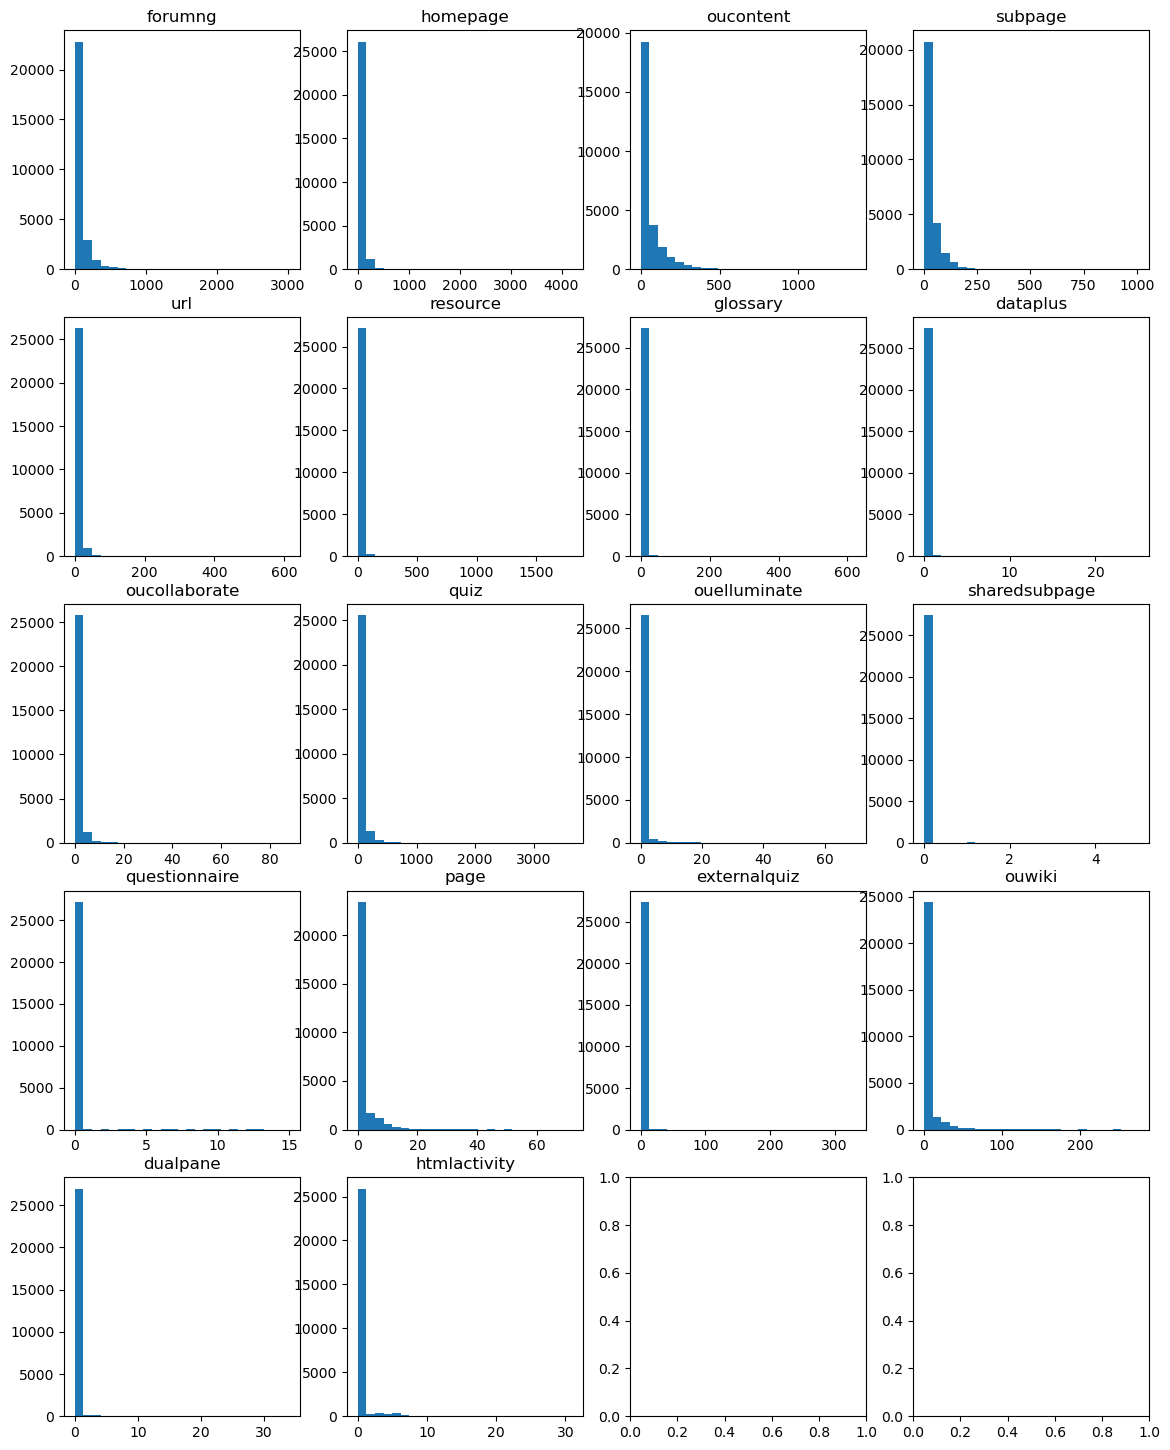

In [61]:
fig, axs = plt.subplots(nrows=5,ncols=4, figsize=(14,18))

for idx, feature in enumerate(vle_feats_n): 
    y, x = idx//4, idx%4
    axs[y, x].hist(df3w[feature],bins=25)
    axs[y, x].set_title(feature)

In [62]:
n = len(df3w)
print("Feature / # / % of students with no instances")
for feature in vle_feats_n:
    z = df3w[feature]
    students_wo_feature = len(z[z==0])
    print(feature, "/", students_wo_feature, "/", students_wo_feature/n)

Feature / # / % of students with no instances
forumng / 5406 / 0.1967463696910143
homepage / 95 / 0.0034574371292353605
oucontent / 3780 / 0.13756960366852278
subpage / 2177 / 0.07922990137205663
url / 7814 / 0.28438330239836956
resource / 3543 / 0.12894420788295666
glossary / 24262 / 0.8829930487316665
dataplus / 27364 / 0.9958874695199621
oucollaborate / 21359 / 0.7773410488772428
quiz / 15377 / 0.5596316919605488
ouelluminate / 25864 / 0.941296356953088
sharedsubpage / 27413 / 0.9976707791971468
questionnaire / 27164 / 0.9886086545110456
page / 21383 / 0.7782145066783128
externalquiz / 23571 / 0.8578447428758598
ouwiki / 21107 / 0.768169741966008
dualpane / 26667 / 0.970520799213888
htmlactivity / 25682 / 0.934672635294974


What if we took logarithms?

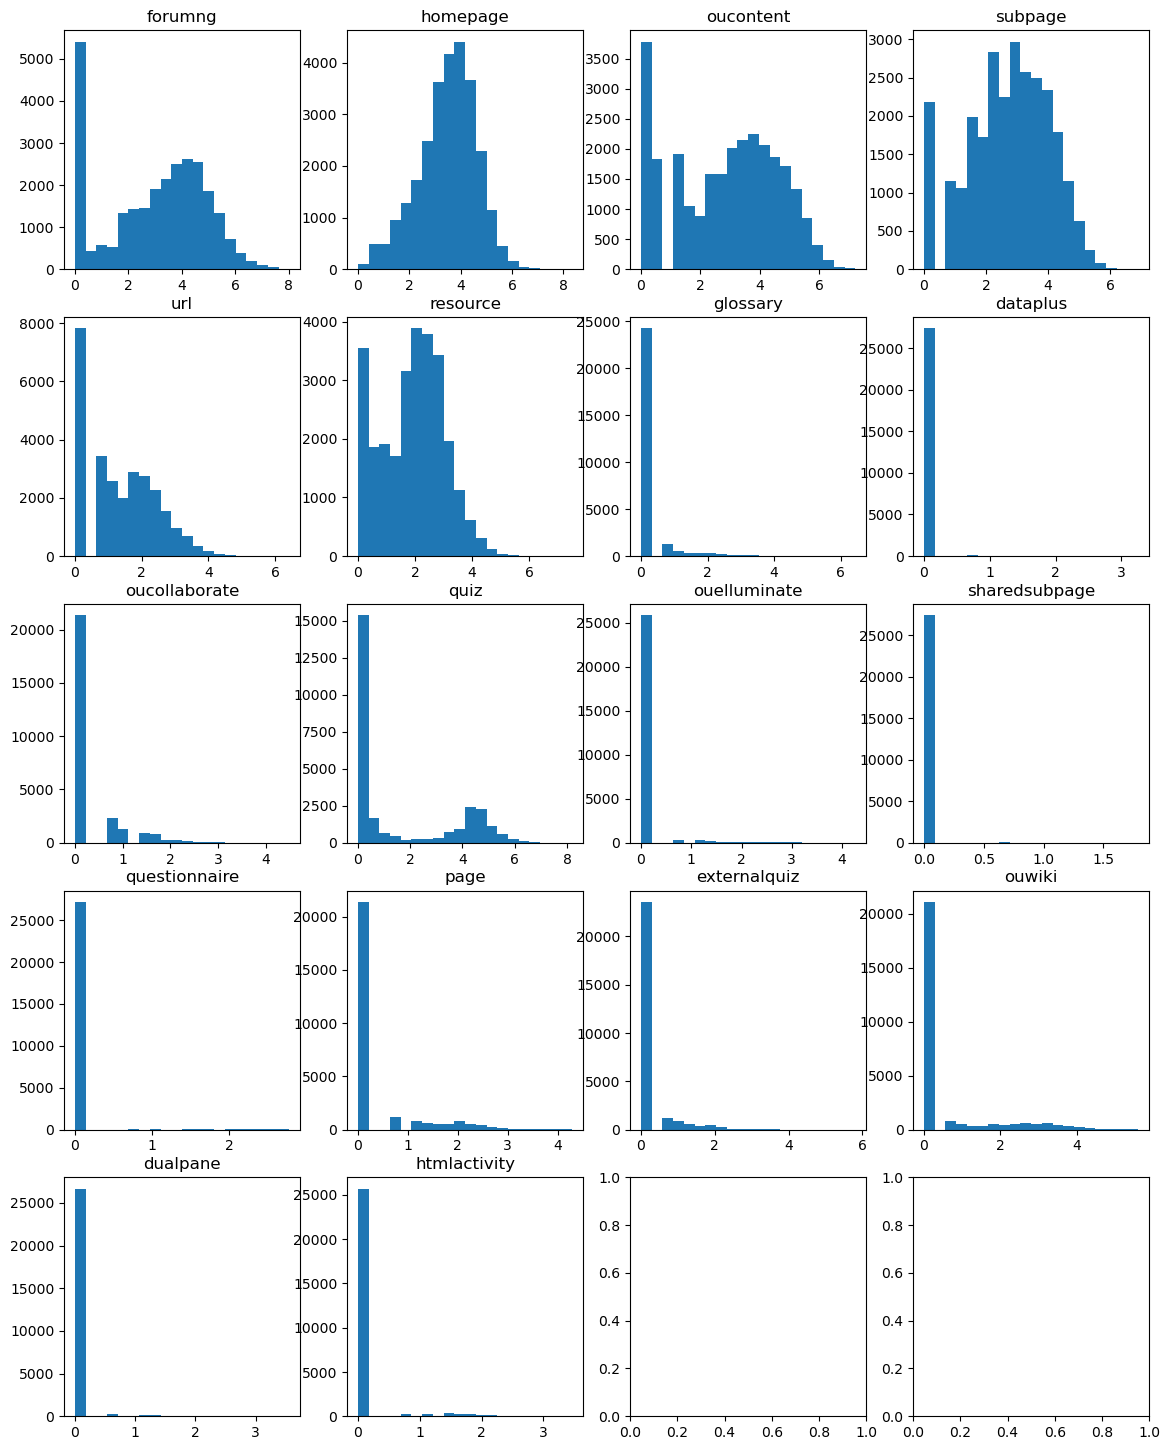

In [63]:
fig, axs = plt.subplots(nrows=5,ncols=4, figsize=(14,18))

for idx, feature in enumerate(vle_feats_n): 
    y, x = idx//4, idx%4
    axs[y, x].hist((df3w[feature]+1).apply(np.log),bins=20)
    axs[y, x].set_title(feature)

I almost feels like it makes sense to discard the features with lots of zeros --- all but `forumng`,`homepage`, `oucontent`, `subpage`, `url`, `resource`. Maybe we can replace the other features with a simple 0 / 1 flag (did the student use the resource during the time period or not?)

### Correlations

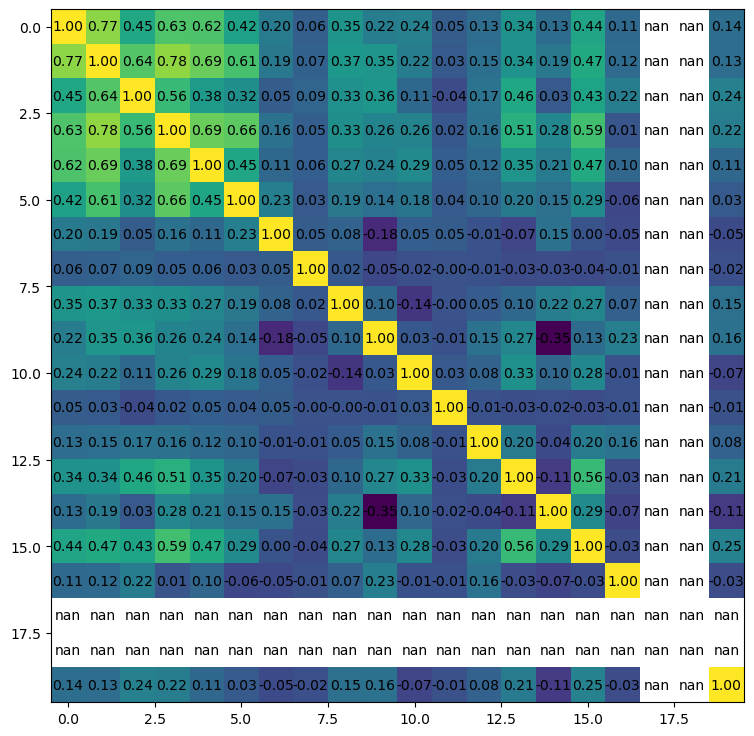

In [64]:
corrs = df3w_vle[vle_feats].corr(method='spearman')

plt.figure(figsize=(9,9))
plt.imshow(corrs, cmap='viridis')

for (j,i), label in np.ndenumerate(corrs):
    plt.text(i,j, f"{label:.2f}", ha='center', va='center', color='black')

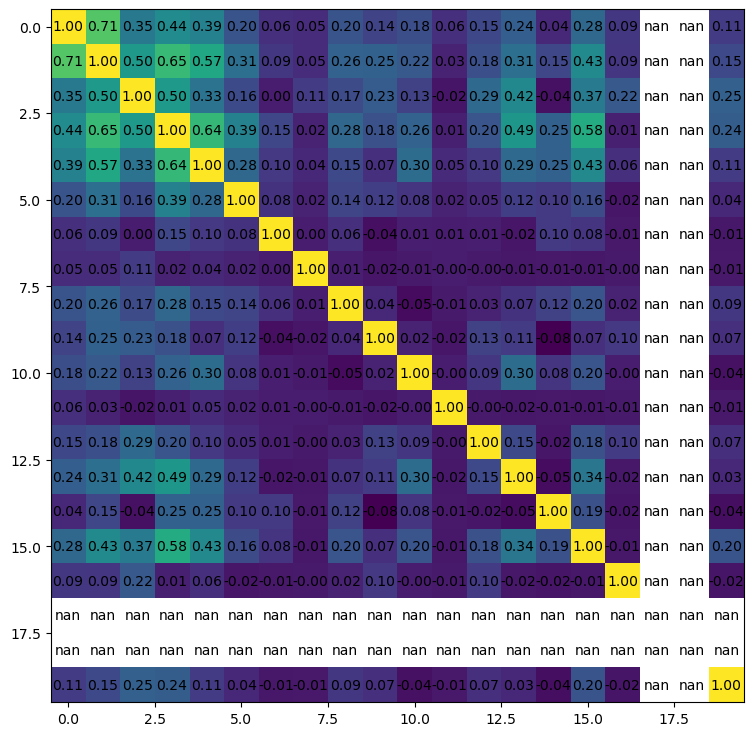

In [65]:
corrs = df3w_vle[vle_feats].corr(method='pearson')

plt.figure(figsize=(9,9))
plt.imshow(corrs, cmap='viridis')

for (j,i), label in np.ndenumerate(corrs):
    plt.text(i,j, f"{label:.2f}", ha='center', va='center', color='black')

 The first six features appear relatively correlated with each other. `homepage` (the second feature) and `subpage` (the fourth feature), in particular, appear quite correlated with a number of other features and possibly should be disregarded (or maybe `homepage` should maybe be read as a sort of "total interaction" feature and is maybe redundant if we include `subpage` and/or `url`.). The remaining correlations do not seem too high. 

In [66]:
df3w_vle.repeatactivity.describe()

count    28520.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: repeatactivity, dtype: float64

In [67]:
df3w_vle.folder.describe()

count    28520.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: folder, dtype: float64

Two of these columns *never* appear (!); we should just drop these. (This also explains why the correlations with these columns are zero --- those columns have zero variance!)

In [68]:
df3w_vle.drop(['folder','repeatactivity'],axis=1,inplace=True)

## Feature engineering 

Now we add engineered features.

In [229]:
vle_feats_n = list(vle_feats[:-3]) + [vle_feats[-1]]
df3w_vle['total_vle']=df3w_vle[vle_feats_n].sum(axis=1)

In [230]:
df3w_vle['vle_richness'] = (df3w_vle[vle_feats_n] > 0).sum(axis=1)

In [231]:
from scipy.stats import entropy

def shannon_entropy(row):
    counts = row.values.astype(float)
    counts = counts[counts > 0]
    if len(counts) == 0:
        return 0
    proportions = counts / counts.sum()
    return entropy(proportions, base=2)

df3w_vle['vle_entropy'] = df3w_vle[vle_feats_n].apply(shannon_entropy, axis=1)

In [232]:
# Categorize VLE types
assessment_types = ['quiz', 'questionnaire', 'externalquiz']
content_types = ['oucontent', 'page', 'resource', 'url', 'homepage']
collaborative_types = ['forumng', 'oucollaborate', 'ouelluminate', 'ouwiki']

#student_totals = df.groupby(['id_student', 'code_module', 'code_presentation'])[vle_feats_n].sum()

# Assessment focus
df3w_vle['assessment_focus'] = df3w_vle[assessment_types].sum(axis=1) / df3w_vle.total_vle
df3w_vle['content_focus'] = df3w_vle[content_types].sum(axis=1) / df3w_vle.total_vle
df3w_vle['collab_focus'] = df3w_vle[collaborative_types].sum(axis=1) / df3w_vle.total_vle
#collaborative_focus = collaborative_focus.fillna(0).rename('collaborative_focus_ratio')

In [233]:
df_assess["rel_submit_date"] = df_assess["due_date"] - df_assess["date"]
df_assess["submission_type"] = np.where(df_assess["rel_submit_date"] < 0, "Late", "Early")

In [234]:
assess_freq = df_assess[df_assess.date < cutoff].groupby(list(tag_feats)).size().rename('assess_freq')
avg_score = df_assess[df_assess.date < cutoff][list(tag_feats)+['score']].groupby(list(tag_feats)).mean()
avg_early = df_assess[df_assess.date < cutoff][list(tag_feats)+['rel_submit_date']].groupby(list(tag_feats)).mean()

submission_type_counts = (
    df_assess[(df_assess.date < cutoff) & (df_assess.assessment_type != "Exam")]
    .groupby(list(tag_feats)+["submission_type"])
    .size()
    .unstack(fill_value=0)  # columns will be 'Early' and 'Late'
)
if "Late" in submission_type_counts: 
    avg_early["prop_early"] = submission_type_counts["Early"] / (submission_type_counts["Early"] + submission_type_counts["Late"])
else: 
    avg_early["prop_early"] = 1

In [235]:
df3w_assess = pd.concat([assess_freq,avg_score,avg_early],axis=1)
df3w_assess.sample(3)

,,,assess_freq,score,rel_submit_date,prop_early
id_student,code_module,code_presentation,,,,
205350,AAA,2013J,1,75.0,0.0,1.0
548403,BBB,2013B,1,60.0,0.0,1.0
572722,DDD,2014J,1,55.0,2.0,1.0


In [236]:
df3w = pd.concat([df3w_vle,df3w_assess],axis=1)

In [237]:
df3w = df3w.drop('module_presentation_length',axis=1)

In [238]:
df3w[vle_feats_n] = df3w[vle_feats_n].fillna(0)
zerofills = ['score','assess_freq','rel_submit_date',
             'assessment_focus','content_focus','collab_focus','total_vle',
             'vle_richness','vle_entropy','prop_early']
df3w[zerofills] = df3w[zerofills].fillna(0)
df3w = df3w.dropna(subset=['gender','imd_band'])

In [239]:
df3w.tail(3)

,,,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,...,total_vle,vle_richness,vle_entropy,assessment_focus,content_focus,collab_focus,assess_freq,score,rel_submit_date,prop_early
id_student,code_module,code_presentation,,,,,,,,,,,,,,,,,,,,,
2698535,EEE,2013J,18.0,26.0,107.0,3.0,4.0,0.0,0.0,0.0,0.0,88.0,...,246.0,6.0,1.845799,0.357724,0.556911,0.073171,0.0,0.0,0.0,0.0
2698577,BBB,2014J,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2.0,2.0,1.000000,0.000000,1.000000,0.000000,1.0,100.0,0.0,1.0
2698588,BBB,2014J,5.0,31.0,29.0,6.0,2.0,7.0,0.0,0.0,1.0,0.0,...,81.0,7.0,2.102413,0.000000,0.851852,0.074074,1.0,100.0,1.0,1.0


In [240]:
# Add (overall) regularity features
def std_regularity(df, student_id_col=list(tag_feats), date_col='date'):
    return df.groupby(student_id_col)[date_col].apply(
        lambda x: x.sort_values().diff().std())    

# Lower values = more regular logins
# Higher values = more intermittent/irregular
df3w["std_regularity"] = std_regularity(df[df.date < cutoff]).fillna(0)
df3w["days_active"] = df[df.date < cutoff].groupby(list(tag_feats)).date.nunique()


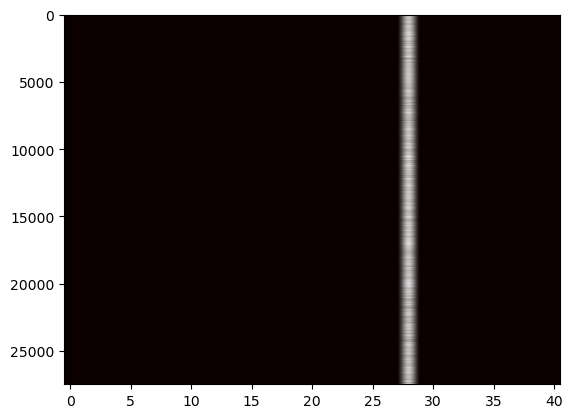

In [241]:
plt.imshow(df3w.isnull(), cmap='hot', aspect='auto')

## Correlation and distribution (engineered features)

Let us now examine correlation between engineered features (+ interaction features)

In [82]:
engineered_feats = df3w.columns[-12:]
engineered_feats

Index(['total_vle', 'vle_richness', 'vle_entropy', 'assessment_focus',
       'content_focus', 'collab_focus', 'assess_freq', 'score',
       'rel_submit_date', 'prop_early', 'std_regularity', 'days_active'],
      dtype='object')

### Distribution of engineered features 

We next look at the distribution of engineered features.

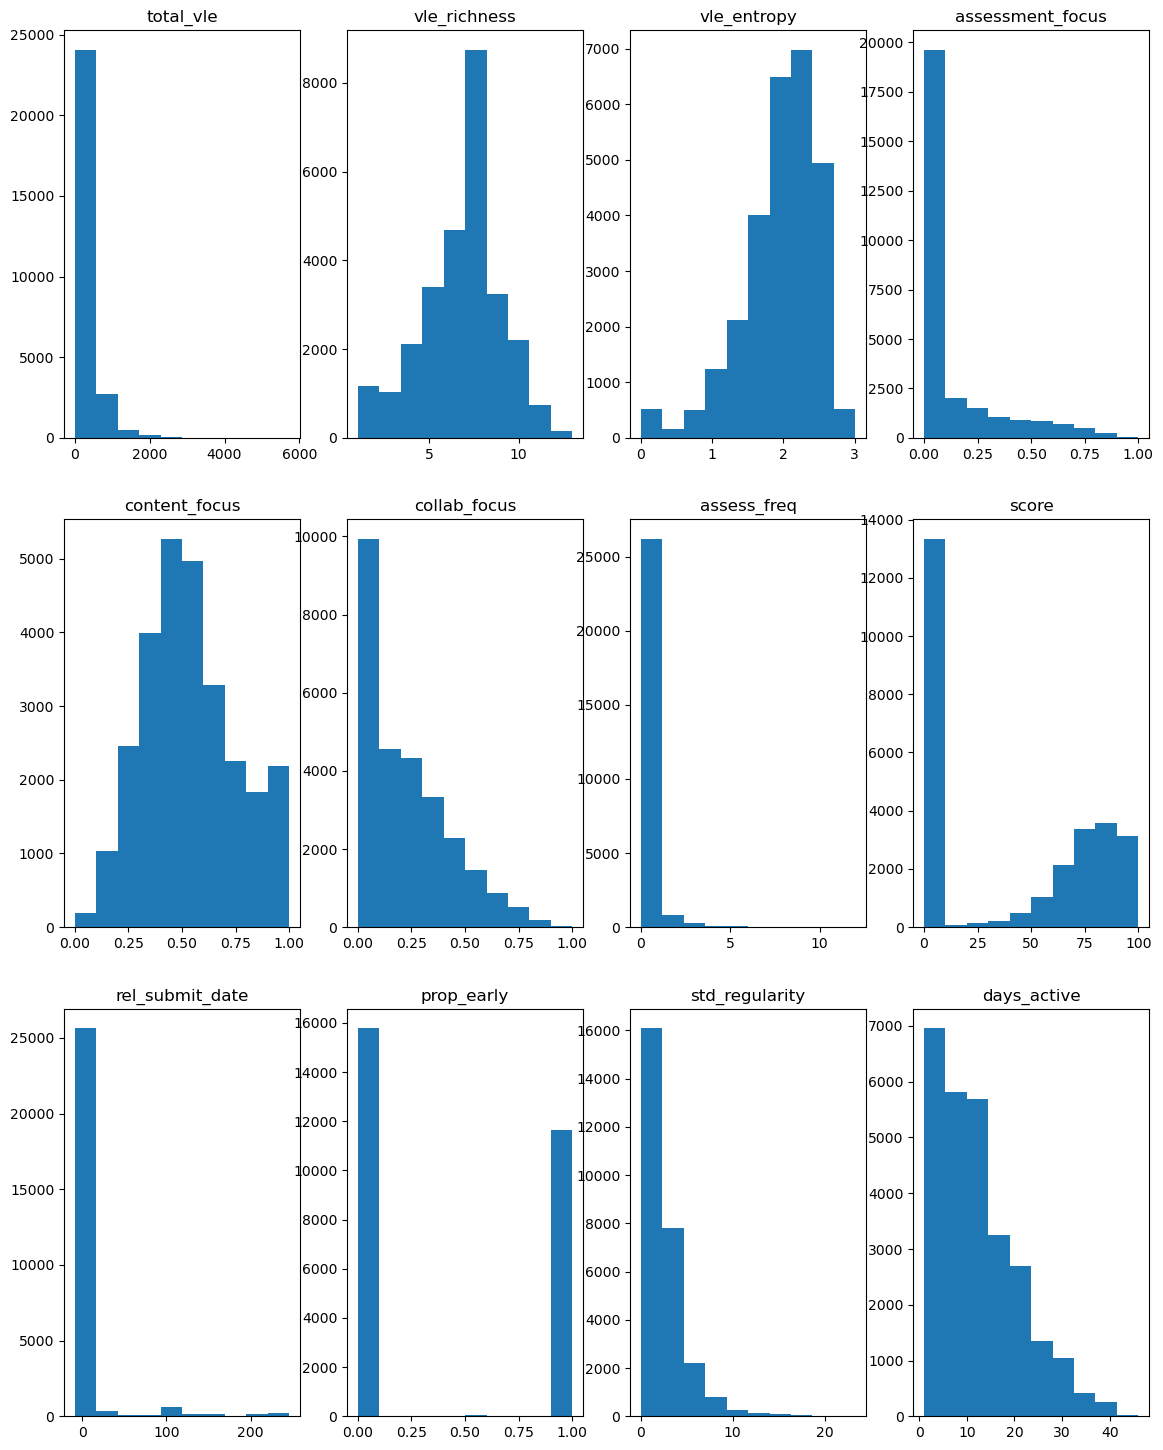

In [83]:
fig, axs = plt.subplots(nrows=3,ncols=4, figsize=(14,18))

for idx, feature in enumerate(engineered_feats): 
    y, x = idx//4, idx%4
    axs[y, x].hist(df3w[feature])
    axs[y, x].set_title(feature)

### Correlations of engineered features

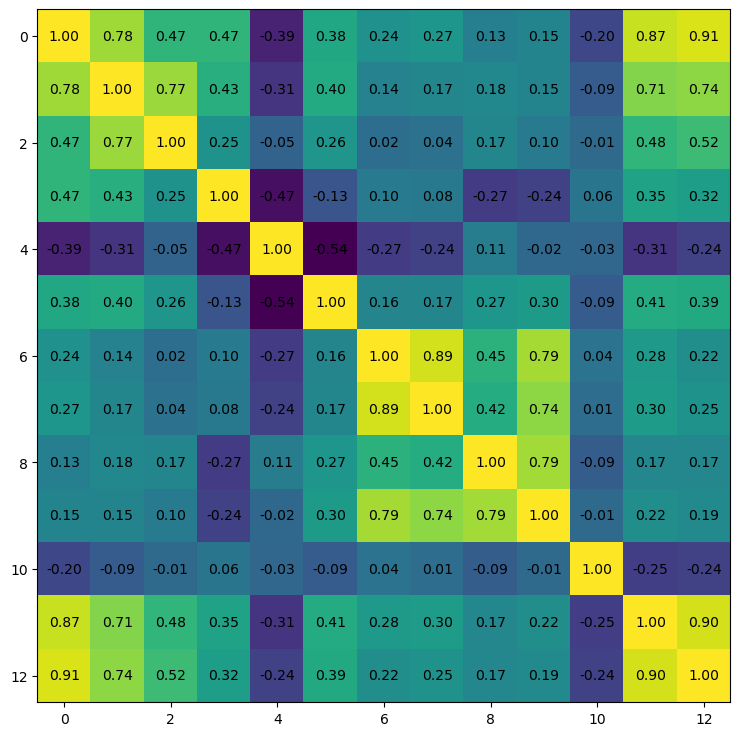

In [84]:
corrs = df3w[list(engineered_feats)+['homepage']].corr(method='spearman')

plt.figure(figsize=(9,9))
plt.imshow(corrs, cmap='viridis')

for (j,i), label in np.ndenumerate(corrs):
    plt.text(i,j, f"{label:.2f}", ha='center', va='center', color='black')

We observe that `vle_total`, `vle_richness`, `days_active`, and `homepage` are all highly correlated with one another. `vle_richness` is also quite correlated with `vle_entropy`. Maybe we can drop some of these features.

Also, the assessment features `assess_freq`, `score`, `rel_submit_date`, `prop_early` are highly correlated with one another. We could probably drop some of them (maybe `assess_freq` and `prop_early`). 

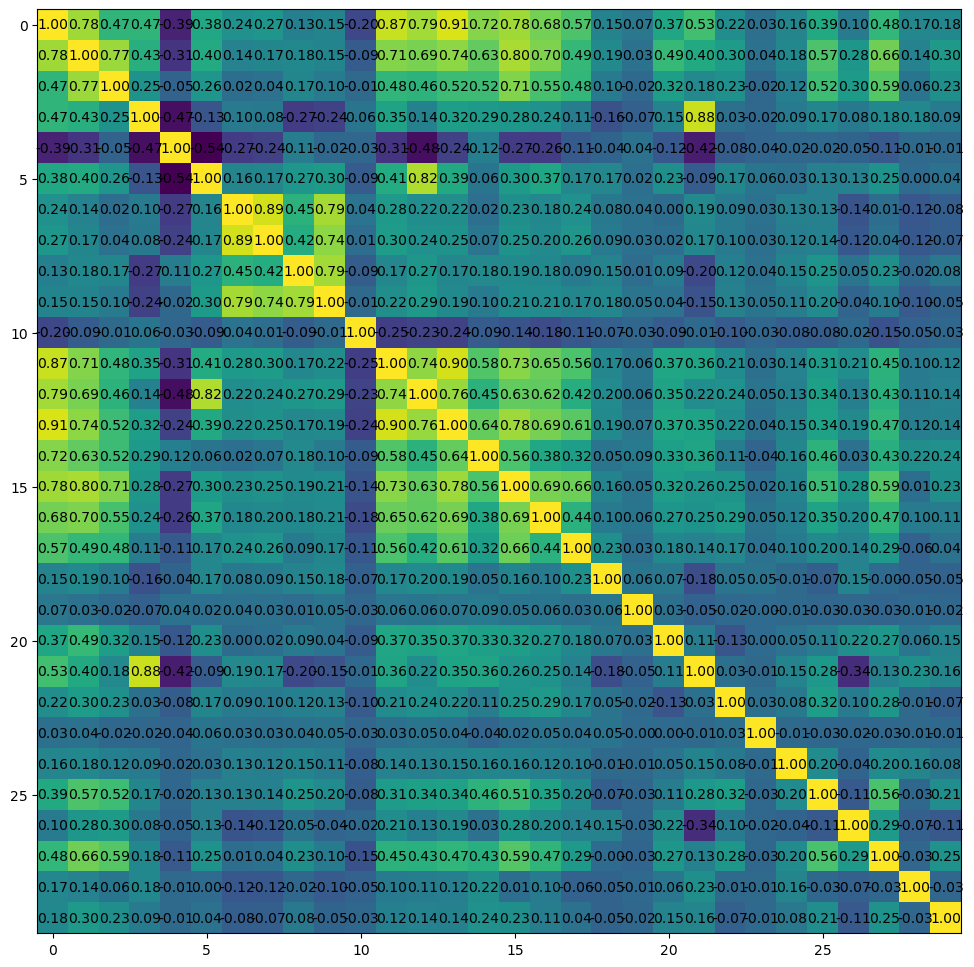

In [85]:
corrs = df3w[list(engineered_feats)+list(vle_feats_n)].corr(method='spearman')

plt.figure(figsize=(12,12))
plt.imshow(corrs, cmap='viridis')

for (j,i), label in np.ndenumerate(corrs):
    plt.text(i,j, f"{label:.2f}", ha='center', va='center', color='black')


Other than the correlations found above, there 's also

In [91]:
(engineered_feats[4], vle_feats_n[9]), (engineered_feats[5], vle_feats_n[0])

(('content_focus', 'quiz'), ('collab_focus', 'forumng'))

## Processing for right skew

We take logarithms for the VLE features with a relatively large proportion of nonzero counts, reduce the other VLE features to binary features, and replace the `rel_submit_date` feature with a signed feature (-1 = late, 0 = on-time, 1 = early).

In [269]:
df3wl = df3w.copy()
for feat in vle_feats_n[:6] + ['total_vle', 'assess_freq', 'std_regularity']:
    df3wl[feat] = df3wl[feat].apply(lambda x:np.log(x+1))
for feat in vle_feats_n[6:]:
    df3wl[feat] = (df3wl[feat]>0).astype(int)
df3wl['rel_submit_date'] = df3wl['rel_submit_date'].apply(np.sign).astype(int)

## VIF analysis for multicollinearity

In [92]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

### Initial attempt

In [ ]:
vif_df3w = pd.DataFrame()
feats = list(df3w.columns[:18])+list(df3w.columns[29:])
vif_df3w.index = feats
vif_df3w["VIF"] = [vif(df3w[feats].values,i) for i in range(len(feats))]

In [98]:
vif_df3w

,VIF
forumng,inf
homepage,inf
oucontent,inf
subpage,inf
url,inf
resource,inf
glossary,inf
dataplus,inf
oucollaborate,inf
quiz,inf


That's ... incredibly bad. Hmm.

Okay so `total_vle` is literally the sum of the VLE features ... maybe if I took logarithms of the VLE features this multicollinearity would go away.

In [156]:
def restricted_vif(restrict_feats, df=df3w):
    vif_df3wr = pd.DataFrame()
    vif_df3wr.index = restrict_feats
    vif_df3wr["VIF"] = [vif(df[restrict_feats].values,i) for i in range(len(restrict_feats))]
    return vif_df3wr.transpose()

In [263]:
restricted_vif(vle_feats_n)

,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,htmlactivity
VIF,2.524043,4.968596,2.500605,5.199249,2.55304,1.536814,1.059798,1.027787,1.240489,1.309602,1.219414,1.012252,1.121349,1.825042,1.237022,1.743309,1.107984,1.211866


In [264]:
restricted_vif(vle_feats_n+['total_vle'],df3wl)

,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,htmlactivity,total_vle
VIF,8.481237,85.048652,8.244211,23.324236,5.609781,8.603275,1.305071,1.048391,1.703874,3.10689,1.386205,1.016667,1.099486,2.670322,1.93157,2.6718,1.220552,1.282384,90.793188


Now the only remaining culprit seems to be `homepage` (and maybe `subpage`)

In [265]:
restricted_vif([vle_feats_n[0]]+vle_feats_n[2:]+['total_vle'],df3wl)

,forumng,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,htmlactivity,total_vle
VIF,8.379006,8.229659,23.268366,5.432848,8.458801,1.303977,1.04837,1.70122,3.064477,1.386204,1.016665,1.098785,2.663592,1.926813,2.670863,1.220014,1.281842,27.757494


In [266]:
restricted_vif([vle_feats_n[0], vle_feats_n[2]]+vle_feats_n[4:]+['total_vle'],df3wl)

,forumng,oucontent,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,htmlactivity,total_vle
VIF,8.372063,8.215914,4.959441,6.745353,1.301729,1.046512,1.701095,3.063365,1.383895,1.016594,1.098551,2.458845,1.806404,2.62546,1.219301,1.259651,23.481814


In [267]:
restricted_vif([vle_feats_n[0]]+vle_feats_n[2:],df3wl)

,forumng,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,htmlactivity
VIF,6.546931,6.061803,19.684178,5.432428,7.889731,1.30278,1.046528,1.684027,2.668937,1.385394,1.016664,1.095639,2.556494,1.913297,2.559435,1.216275,1.276159


In [271]:
restricted_vif([vle_feats_n[0], vle_feats_n[2]]+vle_feats_n[4:],df3wl)

,forumng,oucontent,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,htmlactivity
VIF,6.100476,5.490655,4.885822,4.84443,1.301426,1.045713,1.682108,2.576139,1.381248,1.016589,1.095585,2.432366,1.731071,2.551474,1.213237,1.259312


In [272]:
restrict_vle_feats = [vle_feats_n[0], vle_feats_n[2]] + vle_feats_n[4:]

`vle_entropy` may also be correlated with the three focus features --- those three focus features together may already capture most of the same information captured by `vle_entropy`.

In [273]:
restricted_vif(['vle_entropy',
                  'assessment_focus','content_focus','collab_focus'])

,vle_entropy,assessment_focus,content_focus,collab_focus
VIF,9.668808,1.498019,5.287664,2.618576


While we're at it, we may as well test our hypothesis about the collinearity of the assessment features.

In [210]:
restricted_vif(['assess_freq', 'score', 'rel_submit_date', 'prop_early'])

,assess_freq,score,rel_submit_date,prop_early
VIF,4.805662,5.403593,1.406009,4.10946


### Second attempt

In [276]:
restricted_vif(restrict_vle_feats + list(engineered_feats[2:]), df3wl).transpose()

,VIF
forumng,30.251573
oucontent,10.934257
url,5.635774
resource,7.755725
glossary,1.334856
dataplus,1.053994
oucollaborate,1.719577
quiz,5.196783
ouelluminate,1.388994
sharedsubpage,1.020041


In [277]:
z = restricted_vif(restrict_vle_feats + list(engineered_feats[2:5]) + list(engineered_feats[6:]), df3wl).transpose()
z[z.VIF>5]


,VIF
forumng,11.038829
oucontent,8.477810
url,5.471349
resource,7.410844
quiz,5.149418
vle_entropy,27.878165
content_focus,7.988117
assess_freq,13.249741
score,9.586357
rel_submit_date,5.090981


In [292]:
z = restricted_vif(restrict_vle_feats + list(engineered_feats[3:5]) + list(engineered_feats[6:-1]), df3wl).transpose()
z[z.VIF>5]


,VIF
forumng,7.269430
oucontent,7.689074
url,5.001311
resource,6.175166
quiz,5.008058
content_focus,5.086544
assess_freq,12.982219
score,9.552563
rel_submit_date,5.077381
prop_early,19.439941


In [282]:
restricted_vif(restrict_vle_feats + list(engineered_feats[3:5]) + list(engineered_feats[6:-3])+[engineered_feats[-2]], df3wl).transpose()

,VIF
forumng,7.254268
oucontent,7.674979
url,4.988933
resource,6.148589
glossary,1.323971
dataplus,1.050404
oucollaborate,1.704084
quiz,4.997188
ouelluminate,1.386414
sharedsubpage,1.019245


It seems like in the end the VIF suggests keeping most of the VLE features (except `homepage` and `subpage`, and possibly `quiz`), two of the focus features, most of the assessment features (although the rescaled `rel_submit_date` may be already a good proxy for `prop_early`), and one of the regularity feature (as in the last cell above).

In [290]:
kept_features = restrict_vle_feats + list(engineered_feats[3:5]) + list(engineered_feats[6:-3])+[engineered_feats[-2]]

## Significance analysis

Looking at the distributions above: even after taking logs, many of the features do not look normally distributed (many of the VLE look approximately normal except for a bump at 0). In light of this, ANOVA tests may not be appropriate. Instead, we perform the Kruskal-Wallis H test. 

In [ ]:
from scipy import stats
#sigtest_feats = vle_feats_n + list(engineered_feats)

In [284]:
for feat in sigtest_feats:
    # Get data for each outcome group
    distinction = df3wl[df3wl['final_result'] == 'Distinction'][feat].dropna()
    pass_group = df3wl[df3wl['final_result'] == 'Pass'][feat].dropna()
    fail = df3wl[df3wl['final_result'] == 'Fail'][feat].dropna()
    withdrawn = df3wl[df3wl['final_result'] == 'Withdrawn'][feat].dropna()
    
    # Statistical test
    H_stat, p_value = stats.kruskal(distinction, pass_group, fail, withdrawn)
    
    # Calculate effect size (how much does outcome explain the metric?)
    n = len(pd.concat([distinction, pass_group, fail, withdrawn]))
    eta_squared = (H_stat-3) / (n-4)
    
    print(f"{feat}:"+ f"  p-value: {p_value:.4f};  "+f"eta^2: {eta_squared:.3f}")


forumng:  p-value: 0.0000;  eta^2: 0.073
homepage:  p-value: 0.0000;  eta^2: 0.082
oucontent:  p-value: 0.0000;  eta^2: 0.043
subpage:  p-value: 0.0000;  eta^2: 0.037
url:  p-value: 0.0000;  eta^2: 0.035
resource:  p-value: 0.0000;  eta^2: 0.043
glossary:  p-value: 0.0000;  eta^2: 0.009
dataplus:  p-value: 0.0000;  eta^2: 0.001
oucollaborate:  p-value: 0.0000;  eta^2: 0.011
quiz:  p-value: 0.0000;  eta^2: 0.009
ouelluminate:  p-value: 0.0000;  eta^2: 0.001
sharedsubpage:  p-value: 0.1283;  eta^2: 0.000
questionnaire:  p-value: 0.0000;  eta^2: 0.007
page:  p-value: 0.0069;  eta^2: 0.000
externalquiz:  p-value: 0.0000;  eta^2: 0.002
ouwiki:  p-value: 0.0000;  eta^2: 0.009
dualpane:  p-value: 0.0000;  eta^2: 0.009
htmlactivity:  p-value: 0.0000;  eta^2: 0.002
total_vle:  p-value: 0.0000;  eta^2: 0.084
vle_richness:  p-value: 0.0000;  eta^2: 0.032
vle_entropy:  p-value: 0.0000;  eta^2: 0.010
assessment_focus:  p-value: 0.0000;  eta^2: 0.005
content_focus:  p-value: 0.0000;  eta^2: 0.009
co

In [291]:
for feat in kept_features:
    # Get data for each outcome group
    distinction = df3wl[df3wl['final_result'] == 'Distinction'][feat].dropna()
    pass_group = df3wl[df3wl['final_result'] == 'Pass'][feat].dropna()
    fail = df3wl[df3wl['final_result'] == 'Fail'][feat].dropna()
    withdrawn = df3wl[df3wl['final_result'] == 'Withdrawn'][feat].dropna()
    
    # Statistical test
    H_stat, p_value = stats.kruskal(distinction, pass_group, fail, withdrawn)
    
    # Calculate effect size (how much does outcome explain the metric?)
    n = len(pd.concat([distinction, pass_group, fail, withdrawn]))
    eta_squared = (H_stat-3) / (n-4)
    
    print(f"{feat}:"+ f"  p-value: {p_value:.4f};  "+f"eta^2: {eta_squared:.3f}")


forumng:  p-value: 0.0000;  eta^2: 0.073
oucontent:  p-value: 0.0000;  eta^2: 0.043
url:  p-value: 0.0000;  eta^2: 0.035
resource:  p-value: 0.0000;  eta^2: 0.043
glossary:  p-value: 0.0000;  eta^2: 0.009
dataplus:  p-value: 0.0000;  eta^2: 0.001
oucollaborate:  p-value: 0.0000;  eta^2: 0.011
quiz:  p-value: 0.0000;  eta^2: 0.009
ouelluminate:  p-value: 0.0000;  eta^2: 0.001
sharedsubpage:  p-value: 0.1283;  eta^2: 0.000
questionnaire:  p-value: 0.0000;  eta^2: 0.007
page:  p-value: 0.0069;  eta^2: 0.000
externalquiz:  p-value: 0.0000;  eta^2: 0.002
ouwiki:  p-value: 0.0000;  eta^2: 0.009
dualpane:  p-value: 0.0000;  eta^2: 0.009
htmlactivity:  p-value: 0.0000;  eta^2: 0.002
assessment_focus:  p-value: 0.0000;  eta^2: 0.005
content_focus:  p-value: 0.0000;  eta^2: 0.009
assess_freq:  p-value: 0.0000;  eta^2: 0.036
score:  p-value: 0.0000;  eta^2: 0.069
rel_submit_date:  p-value: 0.0000;  eta^2: 0.038
std_regularity:  p-value: 0.0000;  eta^2: 0.009


Maybe we should drop some of the VLE activities with not many nonzero counts and low eta^2, for instance  `sharedsubpage`, `page`,  `dataplus`, `externalquiz`, `htmlactivity`.
For good measure I also did a one-way ANOVA.

In [206]:
for feat in kept_features:
    # Get data for each outcome group
    distinction = df3wl[df3wl['final_result'] == 'Distinction'][feat].dropna()
    pass_group = df3wl[df3wl['final_result'] == 'Pass'][feat].dropna()
    fail = df3wl[df3wl['final_result'] == 'Fail'][feat].dropna()
    withdrawn = df3wl[df3wl['final_result'] == 'Withdrawn'][feat].dropna()
    
    # Statistical test
    f_stat, p_value = stats.f_oneway(distinction, pass_group, fail, withdrawn)
    
    # Calculate effect size (how much does outcome explain the metric?)
    all_data = pd.concat([distinction, pass_group, fail, withdrawn])
    grand_mean = all_data.mean()
    
    ss_between = (len(distinction) * (distinction.mean() - grand_mean)**2 +
                  len(pass_group) * (pass_group.mean() - grand_mean)**2 +
                  len(fail) * (fail.mean() - grand_mean)**2 +
                  len(withdrawn) * (withdrawn.mean() - grand_mean)**2)
    
    ss_total = ((all_data - grand_mean)**2).sum()
    eta_squared = ss_between / ss_total if ss_total > 0 else 0
    
    print(f"{feat}:"+ f"  p-value: {p_value:.4f};  "+f"eta^2: {eta_squared:.3f}")


forumng:  p-value: 0.0000;  eta^2: 0.071
oucontent:  p-value: 0.0000;  eta^2: 0.041
url:  p-value: 0.0000;  eta^2: 0.035
resource:  p-value: 0.0000;  eta^2: 0.043
glossary:  p-value: 0.0000;  eta^2: 0.006
dataplus:  p-value: 0.0003;  eta^2: 0.001
oucollaborate:  p-value: 0.0000;  eta^2: 0.011
quiz:  p-value: 0.0000;  eta^2: 0.016
ouelluminate:  p-value: 0.0000;  eta^2: 0.001
sharedsubpage:  p-value: 0.3174;  eta^2: 0.000
questionnaire:  p-value: 0.0000;  eta^2: 0.008
page:  p-value: 0.0000;  eta^2: 0.001
externalquiz:  p-value: 0.0000;  eta^2: 0.001
ouwiki:  p-value: 0.0000;  eta^2: 0.018
dualpane:  p-value: 0.0000;  eta^2: 0.008
htmlactivity:  p-value: 0.0000;  eta^2: 0.002
assessment_focus:  p-value: 0.0000;  eta^2: 0.002
content_focus:  p-value: 0.0000;  eta^2: 0.010
assess_freq:  p-value: 0.0000;  eta^2: 0.023
score:  p-value: 0.0000;  eta^2: 0.061
rel_submit_date:  p-value: 0.0000;  eta^2: 0.006
prop_early:  p-value: 0.0000;  eta^2: 0.050
std_regularity:  p-value: 0.0000;  eta^2: 

In [293]:
kept_features = ['forumng','oucontent','url','resource','glossary','oucollaborate',
                 'quiz','questionnaire','ouwiki','dualpane',
                 'assessment_focus','content_focus',
                 'assess_freq','score','rel_submit_date','std_regularity']